# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility
tf.random.set_seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/LSTM'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

In [5]:
FEATURES = [
    'year', 'month', 'day_of_week', 'day_of_year', 'week_of_year',
    'is_weekend', 'is_holiday', 'tavg', 'prcp',
    'is_after_weekend', 'is_after_holiday', 'is_after_gap',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7_mean', 'rolling_7_std', 'rolling_30_mean',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]

TARGET = 'total_tonnes'

LOOKBACK = 30

# Model Definition - LSTM

## Helper functions

In [6]:
def create_sequences(data, target_idx, lookback):
    """
    Create input sequences and target values for LSTM.
    Each sample: X = [lookback days of all features], y = next day's target.
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, :])   # all features for past N days
        y.append(data[i, target_idx])       # target for current day
    return np.array(X), np.array(y)


def build_lstm_model(input_shape, units=64):
    """Build a 2-layer LSTM model."""
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units // 2, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Model function

In [12]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error — robust to zero values."""
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    if mask.sum() == 0:
        return float('nan')
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100

def run_lstm_prediction(df, dataset_name, dataset_code, dataset_number, features, split_days=90,
                        n_splits=3, lookback=30, epochs=50, batch_size=32, TARGET='total_tonnes', VIS_DIR='.'):
    """
    Train LSTM with rolling-origin validation.
    Plots are generated ONLY for the best split (lowest sMAPE).
    """
    print(f"\n{'='*100}")
    print(f"LSTM PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # feature selection
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"Note: Missing features (skipped): {missing_features}")

    if TARGET not in available_features and TARGET in df.columns:
        available_features.append(TARGET)

    # dropping NaN
    cols_to_check = [TARGET] + available_features

    cols_to_check = list(dict.fromkeys(cols_to_check))
    df_valid = df.dropna(subset=cols_to_check).reset_index(drop=True)
    print(f"Total rows: {len(df)}, Valid (non-NaN in target & features): {len(df_valid)}")

    target_idx = available_features.index(TARGET)


    # ============================================================
    # ROLLING-ORIGIN VALIDATION
    # ============================================================
    split_results = []
    total_needed = lookback + split_days * n_splits

    if len(df_valid) < total_needed + 100:
        print(f"WARNING: Not enough data for {n_splits} splits of {split_days} days.")
        print(f"Reducing to 2 splits.")
        n_splits = 2

    print(f"\nRolling-origin validation: {n_splits} splits of {split_days} days each (lookback={lookback})")

    best_smape = float('inf')
    best_split_data = None

    for split_idx in range(n_splits):
        offset = (n_splits - 1 - split_idx) * split_days

        # data split
        if offset == 0:
            df_train = df_valid.iloc[:-split_days].copy()
            df_test = df_valid.iloc[-split_days:].copy()
        else:
            df_train = df_valid.iloc[:-(offset + split_days)].copy()
            df_test = df_valid.iloc[-(offset + split_days):-offset].copy()

        print(f"\n--- Split {split_idx+1}/{n_splits} ---")
        print(f"Train: {len(df_train)} days ({df_train['date'].min().date()} → {df_train['date'].max().date()})")
        print(f"Test:  {len(df_test)} days ({df_test['date'].min().date()} → {df_test['date'].max().date()})")

        df_combined = pd.concat([df_train, df_test]).reset_index(drop=True)
        split_point = len(df_train)

        data = df_combined[available_features].values.astype(np.float32)
        dates = df_combined['date'].values

        # feature scaling (FIT ONLY ON TRAIN to avoid data leakage)
        scaler = MinMaxScaler()
        scaler.fit(data[:split_point])
        data_scaled = scaler.transform(data)

        target_scaler = MinMaxScaler()
        target_scaler.fit(data[:split_point, target_idx].reshape(-1, 1))

        # create sequences
        train_data = data_scaled[:split_point]
        X_train, y_train = create_sequences(train_data, target_idx, lookback)

        test_data = data_scaled[split_point - lookback:]
        X_test, y_test = create_sequences(test_data, target_idx, lookback)
        test_dates = dates[split_point:]

        # model fit
        tf.keras.backend.clear_session()
        model = build_lstm_model(input_shape=(lookback, len(available_features)))
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        history = model.fit(
            X_train, y_train,
            validation_split=0.15,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0  # set to 0 to avoid massive log output for each split
        )

        epochs_run = len(history.history['loss'])
        print(f"Training finished at epoch {epochs_run}")

        y_pred_scaled = model.predict(X_test, verbose=0).flatten()

        # inverse transform predictions and actuals
        y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

        # clip negatives
        y_pred = np.clip(y_pred, 0, None)

        # metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape_val = smape(y_true, y_pred)

        split_results.append({'mae': mae, 'rmse': rmse, 'smape': smape_val, 'epochs_trained': epochs_run})
        print(f"MAE: {mae:.2f}t | RMSE: {rmse:.2f}t | sMAPE: {smape_val:.2f}%")

        # Track best split
        if smape_val < best_smape:
            best_smape = smape_val
            best_split_data = {
                'split_idx': split_idx + 1,
                'test_dates': test_dates,
                'y_true': y_true,
                'y_pred': y_pred,
                'mae': mae,
                'rmse': rmse,
                'smape': smape_val,
                'history': history.history,
                'epochs_run': epochs_run
            }


    # ============================================================
    # AVERAGE METRICS ACROSS SPLITS
    # ============================================================
    avg_mae = np.mean([r['mae'] for r in split_results])
    avg_rmse = np.mean([r['rmse'] for r in split_results])
    avg_smape = np.mean([r['smape'] for r in split_results])
    avg_epochs = int(np.mean([r['epochs_trained'] for r in split_results]))

    print(f"\n--- AVERAGE ACROSS {n_splits} SPLITS ---")
    print(f"MAE:   {avg_mae:.2f} tonnes")
    print(f"RMSE:  {avg_rmse:.2f} tonnes")
    print(f"sMAPE: {avg_smape:.2f}%")
    print(f"Best split was Split {best_split_data['split_idx']} (sMAPE: {best_split_data['smape']:.2f}%)")


    # ============================================================
    # PLOT — BEST SPLIT ONLY
    # ============================================================
    b_hist = best_split_data['history']
    test_dates_dt = pd.to_datetime(best_split_data['test_dates'])
    y_true_plot = best_split_data['y_true']
    y_pred_plot = best_split_data['y_pred']


    # --- Plot 3X1: Training history - LSTM ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(b_hist['loss'], label='Train Loss')
    if 'val_loss' in b_hist: axes[0].plot(b_hist['val_loss'], label='Validation Loss')
    axes[0].set_title(f"Model Loss (Best Split: #{best_split_data['split_idx']})", fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()

    axes[1].plot(b_hist['mae'], label='Train MAE')
    if 'val_mae' in b_hist: axes[1].plot(b_hist['val_mae'], label='Validation MAE')
    axes[1].set_title(f"Model MAE (Best Split: #{best_split_data['split_idx']})", fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'3{dataset_number}1_lstm_training_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # --- Plot 3X2: Actual vs Predicted (test period) ---
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(test_dates_dt, y_true_plot, color='steelblue', linewidth=1.5, label='Actual (Test)')
    ax.plot(test_dates_dt, y_pred_plot, color='red', linewidth=1.5, linestyle='--', label='LSTM Forecast')
    ax.set_title(f"LSTM Forecast vs Actual — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)
    ax.text(0.02, 0.95, f"Best Split Metrics:\nMAE: {best_split_data['mae']:.2f}t\nRMSE: {best_split_data['rmse']:.2f}t\nsMAPE: {best_split_data['smape']:.1f}%",
            transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    plt.tight_layout()
    plt.savefig(os.path.join(VIS_DIR, f'3{dataset_number}2_lstm_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 3X3: Zoom on first 30 days of test ---
    fig, ax = plt.subplots(figsize=(14, 5))
    zoom_days = min(30, len(y_true_plot))
    ax.plot(test_dates_dt[:zoom_days], y_true_plot[:zoom_days], color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')
    ax.plot(test_dates_dt[:zoom_days], y_pred_plot[:zoom_days], color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='LSTM')
    ax.set_title(f"LSTM Forecast Zoom — {dataset_name} (Best Split: #{best_split_data['split_idx']})", fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'3{dataset_number}3_lstm_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # cleanup
    tf.keras.backend.clear_session()

    return {
        'dataset': dataset_name,
        'model': 'LSTM',
        'mae': round(avg_mae, 2),
        'rmse': round(avg_rmse, 2),
        'smape': round(avg_smape, 2),
        'n_splits': n_splits,
        'split_days': split_days,
        'epochs_trained': avg_epochs,
        'lookback': lookback,
        'split_details': split_results
    }

# Model Prediction - LSTM


LSTM PREDICTION — Boralesgamuwa UC (Sri Lanka)
Total rows: 2527, Valid (non-NaN in target & features): 2387

Rolling-origin validation: 3 splits of 90 days each (lookback=30)

--- Split 1/3 ---
Train: 2117 days (2012-01-31 → 2018-03-26)
Test:  90 days (2018-03-28 → 2018-06-28)
Training finished at epoch 11
MAE: 8.50t | RMSE: 10.39t | sMAPE: 31.90%

--- Split 2/3 ---
Train: 2207 days (2012-01-31 → 2018-06-28)
Test:  90 days (2018-06-29 → 2018-09-29)
Training finished at epoch 6
MAE: 6.24t | RMSE: 8.33t | sMAPE: 26.41%

--- Split 3/3 ---
Train: 2297 days (2012-01-31 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)


Training finished at epoch 6


MAE: 6.89t | RMSE: 9.08t | sMAPE: 26.64%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   7.21 tonnes
RMSE:  9.27 tonnes
sMAPE: 28.32%
Best split was Split 2 (sMAPE: 26.41%)


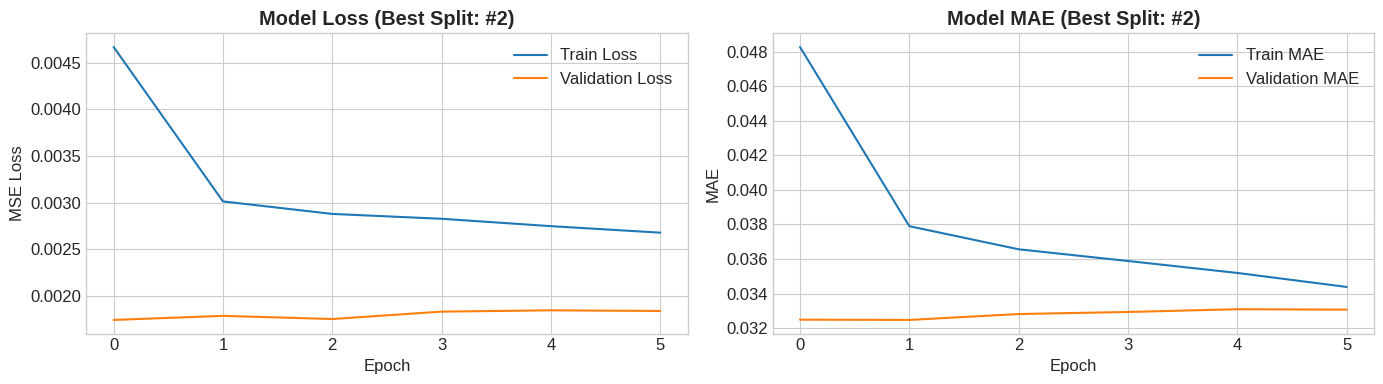

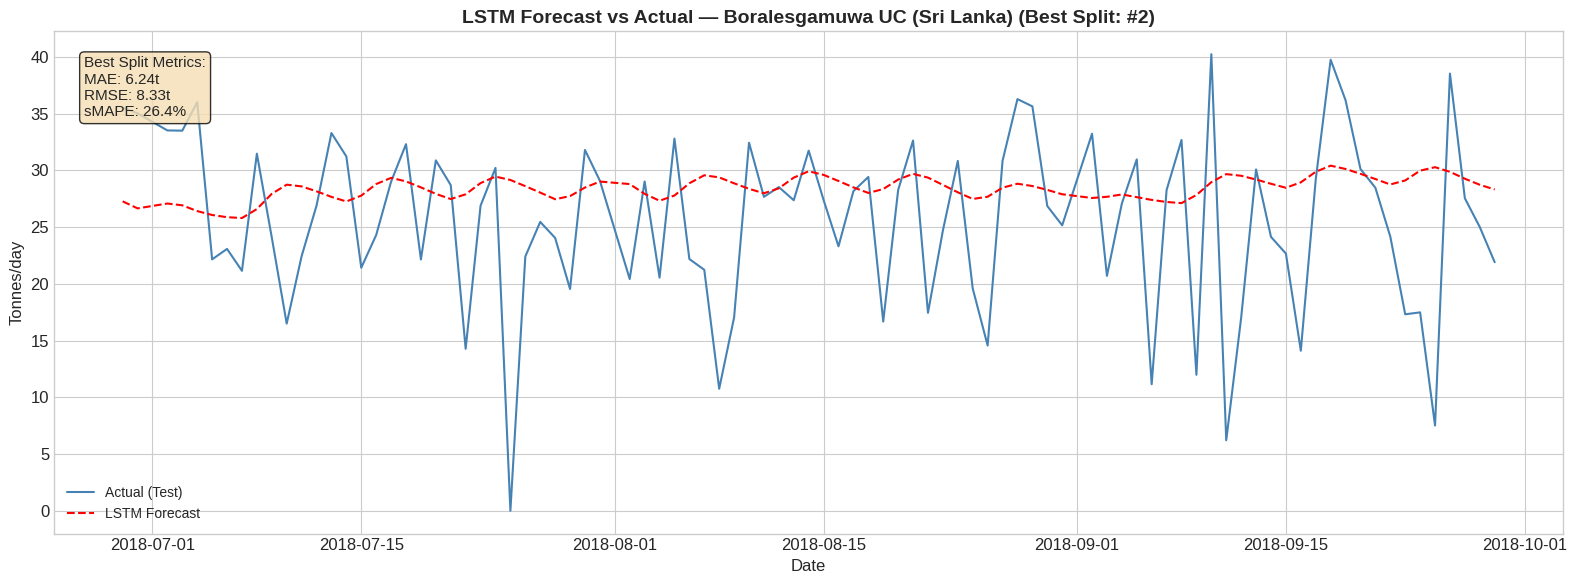

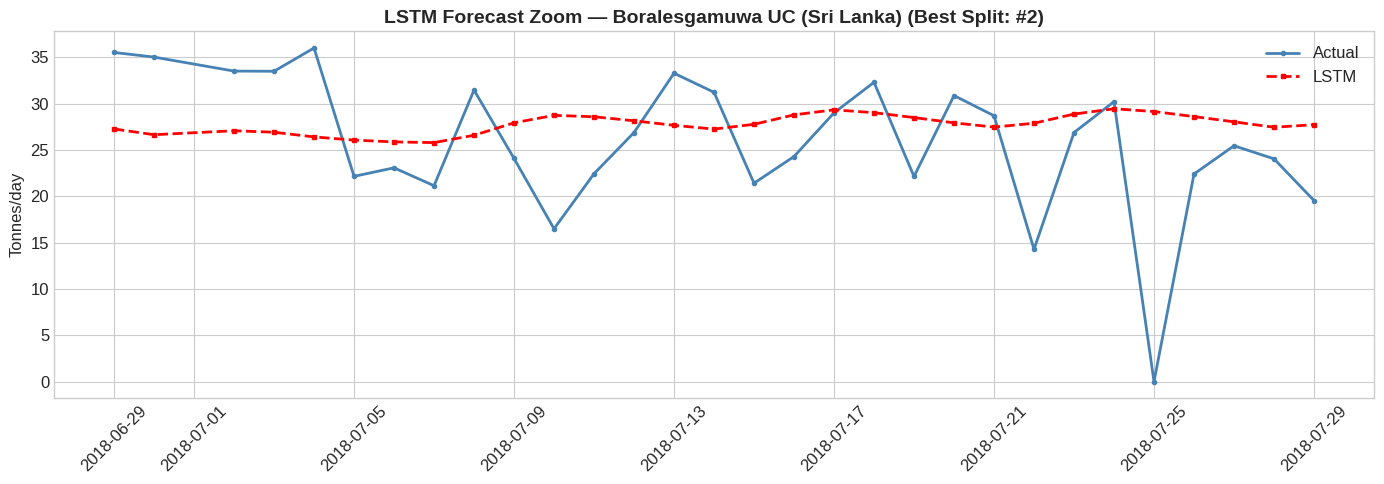


LSTM PREDICTION — Dehiwala MC (Sri Lanka)
Total rows: 1431, Valid (non-NaN in target & features): 1403

Rolling-origin validation: 3 splits of 90 days each (lookback=30)

--- Split 1/3 ---
Train: 1133 days (2012-01-31 → 2015-03-28)
Test:  90 days (2015-03-29 → 2015-07-01)
Training finished at epoch 6
MAE: 30.57t | RMSE: 39.23t | sMAPE: 21.27%

--- Split 2/3 ---
Train: 1223 days (2012-01-31 → 2015-07-01)
Test:  90 days (2015-07-02 → 2015-09-29)
Training finished at epoch 6
MAE: 42.40t | RMSE: 54.89t | sMAPE: 35.07%

--- Split 3/3 ---
Train: 1313 days (2012-01-31 → 2015-09-29)
Test:  90 days (2015-09-30 → 2015-12-31)
Training finished at epoch 6
MAE: 35.89t | RMSE: 43.65t | sMAPE: 27.19%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   36.29 tonnes
RMSE:  45.92 tonnes
sMAPE: 27.85%
Best split was Split 1 (sMAPE: 21.27%)


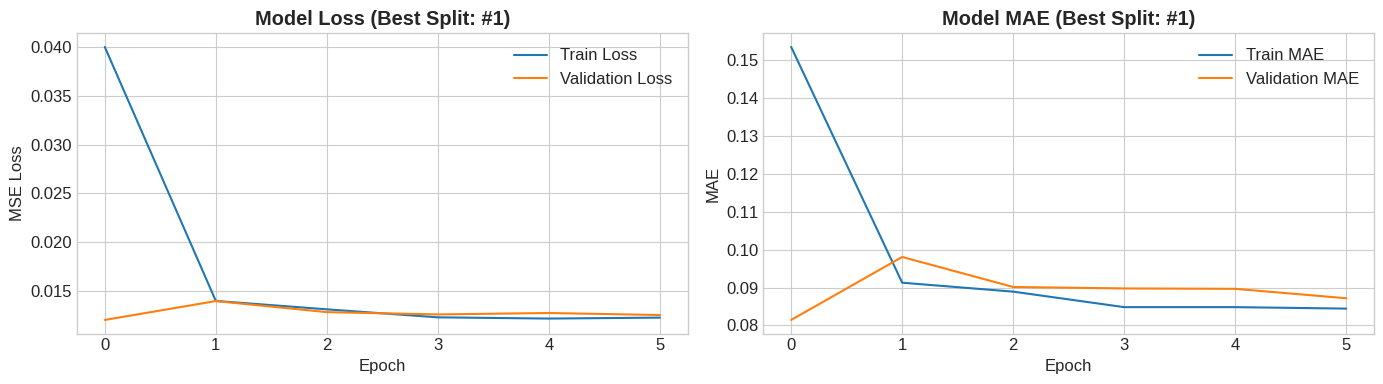

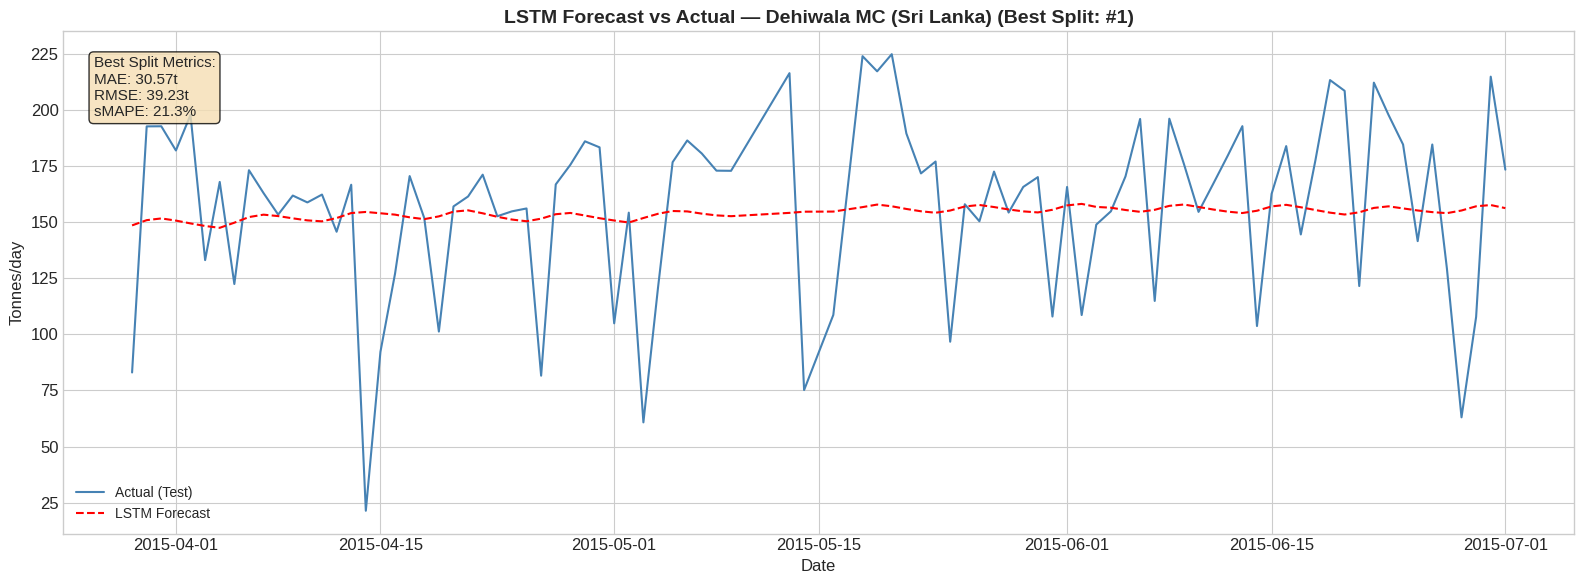

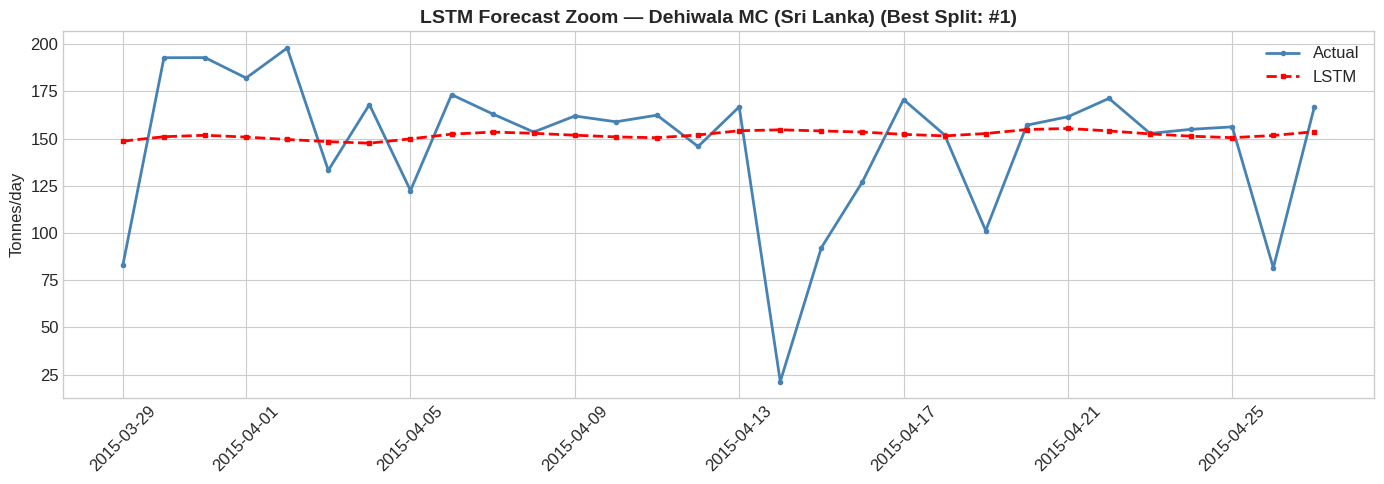


LSTM PREDICTION — Homagama PS (Sri Lanka)
Total rows: 2526, Valid (non-NaN in target & features): 2038

Rolling-origin validation: 3 splits of 90 days each (lookback=30)

--- Split 1/3 ---
Train: 1768 days (2012-02-02 → 2018-03-21)
Test:  90 days (2018-03-22 → 2018-06-25)
Training finished at epoch 11
MAE: 12.32t | RMSE: 16.17t | sMAPE: 35.76%

--- Split 2/3 ---
Train: 1858 days (2012-02-02 → 2018-06-25)
Test:  90 days (2018-06-26 → 2018-09-29)
Training finished at epoch 8
MAE: 9.59t | RMSE: 12.29t | sMAPE: 30.88%

--- Split 3/3 ---
Train: 1948 days (2012-02-02 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
Training finished at epoch 11
MAE: 11.14t | RMSE: 14.84t | sMAPE: 31.84%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   11.02 tonnes
RMSE:  14.43 tonnes
sMAPE: 32.83%
Best split was Split 2 (sMAPE: 30.88%)


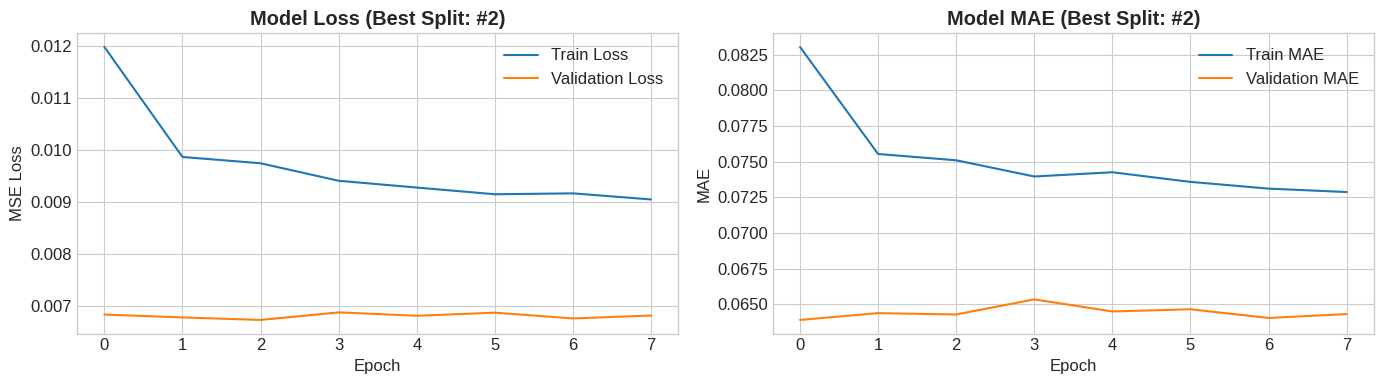

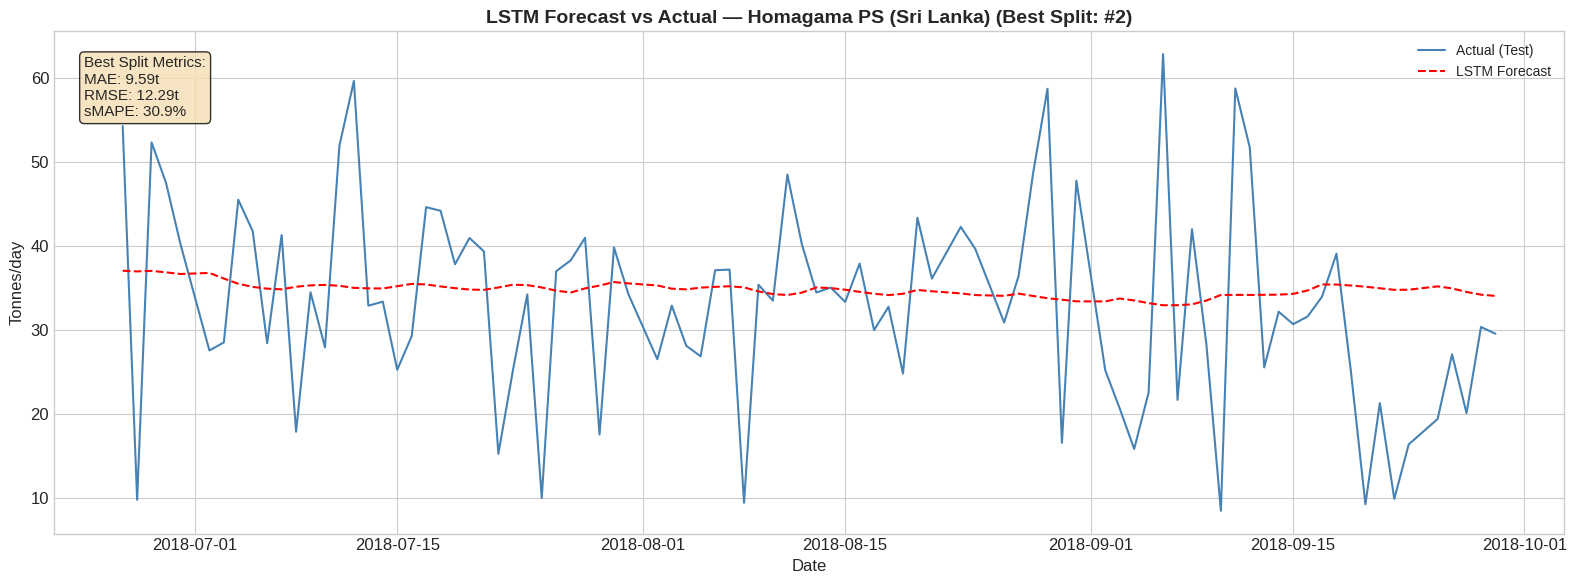

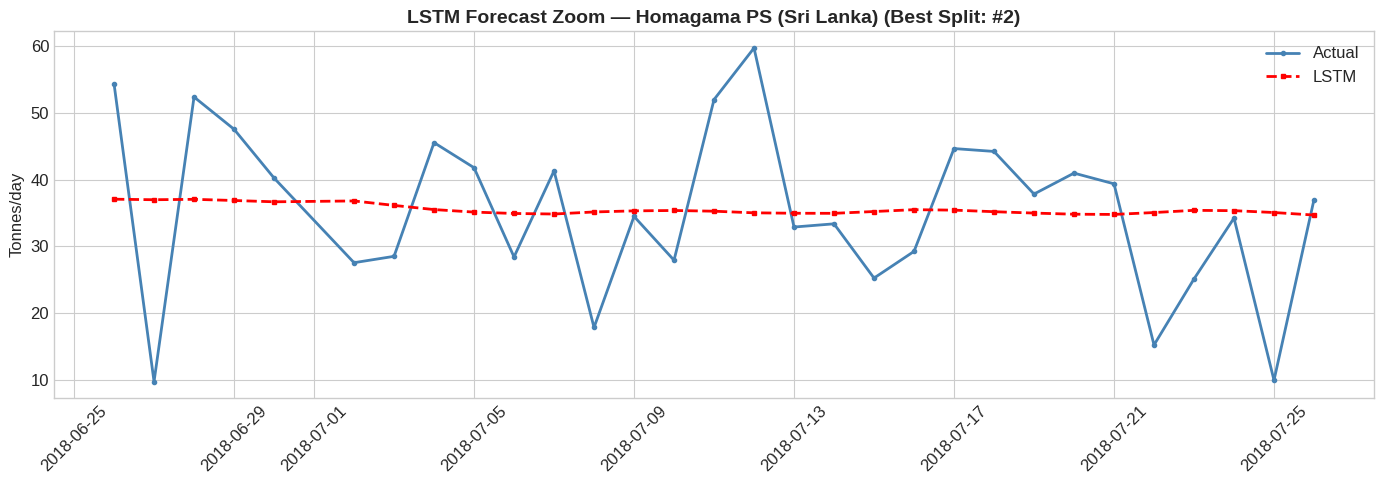


LSTM PREDICTION — Moratuwa MC (Sri Lanka)
Total rows: 1411, Valid (non-NaN in target & features): 1278

Rolling-origin validation: 3 splits of 90 days each (lookback=30)

--- Split 1/3 ---
Train: 1008 days (2015-01-31 → 2018-02-26)
Test:  90 days (2018-02-27 → 2018-06-03)
Training finished at epoch 16
MAE: 16.97t | RMSE: 22.57t | sMAPE: 25.24%

--- Split 2/3 ---
Train: 1098 days (2015-01-31 → 2018-06-03)
Test:  90 days (2018-06-04 → 2018-09-08)
Training finished at epoch 18
MAE: 16.21t | RMSE: 21.33t | sMAPE: 23.17%

--- Split 3/3 ---
Train: 1188 days (2015-01-31 → 2018-09-08)
Test:  90 days (2018-09-09 → 2018-12-11)
Training finished at epoch 15
MAE: 16.94t | RMSE: 22.79t | sMAPE: 25.73%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   16.71 tonnes
RMSE:  22.23 tonnes
sMAPE: 24.71%
Best split was Split 2 (sMAPE: 23.17%)


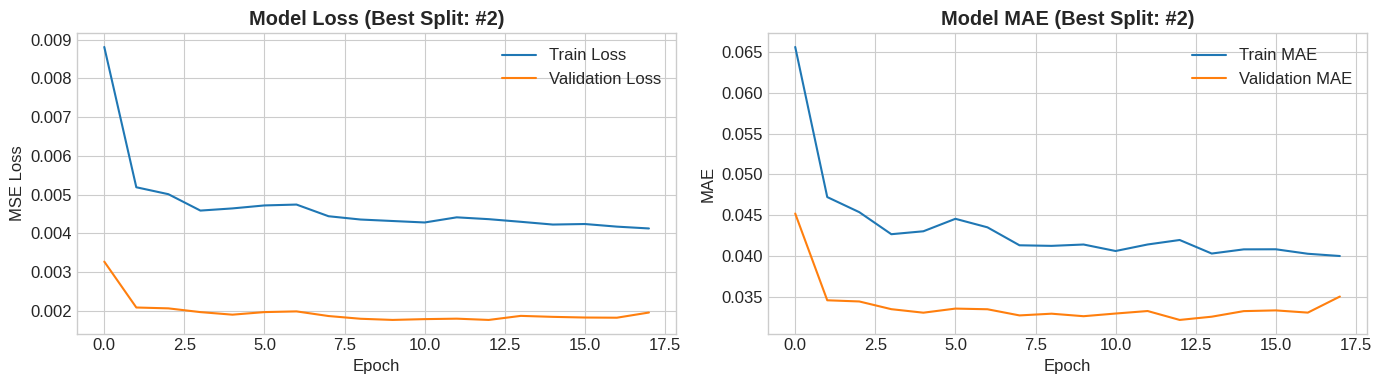

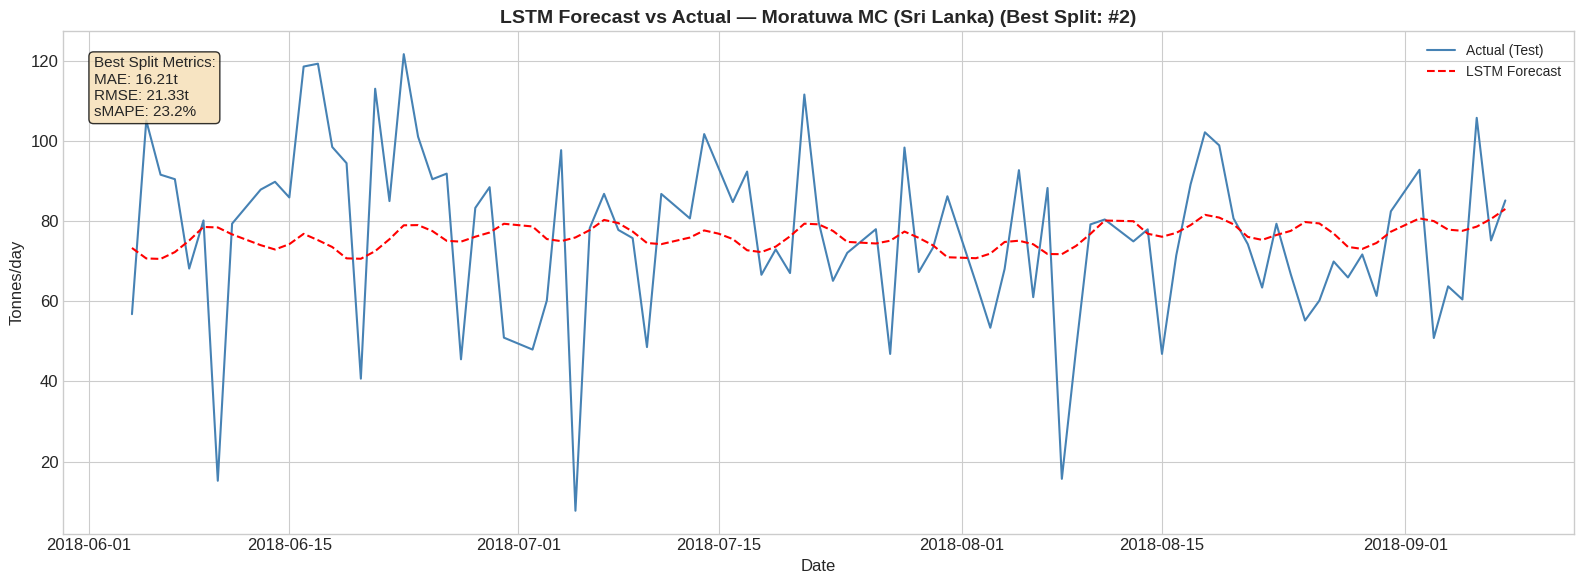

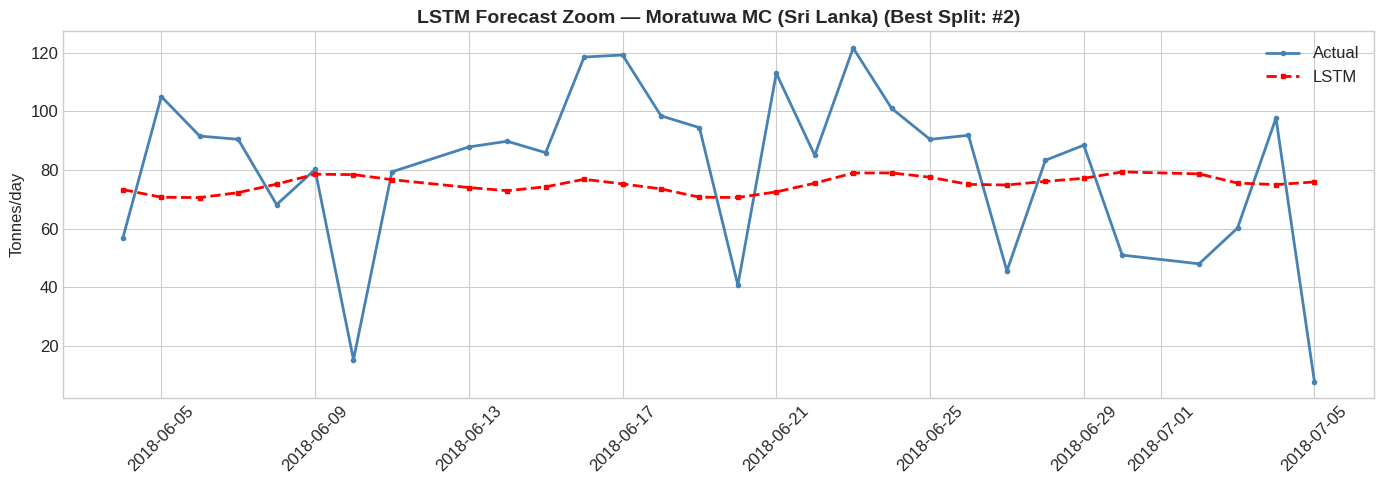


LSTM PREDICTION — Austin TX (USA)
Total rows: 5813, Valid (non-NaN in target & features): 5803

Rolling-origin validation: 3 splits of 90 days each (lookback=30)

--- Split 1/3 ---
Train: 5533 days (2005-02-01 → 2020-04-04)
Test:  90 days (2020-04-05 → 2020-07-03)
Training finished at epoch 35
MAE: 138.83t | RMSE: 198.18t | sMAPE: 47.77%

--- Split 2/3 ---
Train: 5623 days (2005-02-01 → 2020-07-03)
Test:  90 days (2020-07-04 → 2020-10-01)
Training finished at epoch 29
MAE: 121.84t | RMSE: 162.99t | sMAPE: 47.64%

--- Split 3/3 ---
Train: 5713 days (2005-02-01 → 2020-10-01)
Test:  90 days (2020-10-02 → 2020-12-31)
Training finished at epoch 37
MAE: 269.94t | RMSE: 406.23t | sMAPE: 32.05%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   176.87 tonnes
RMSE:  255.80 tonnes
sMAPE: 42.48%
Best split was Split 3 (sMAPE: 32.05%)


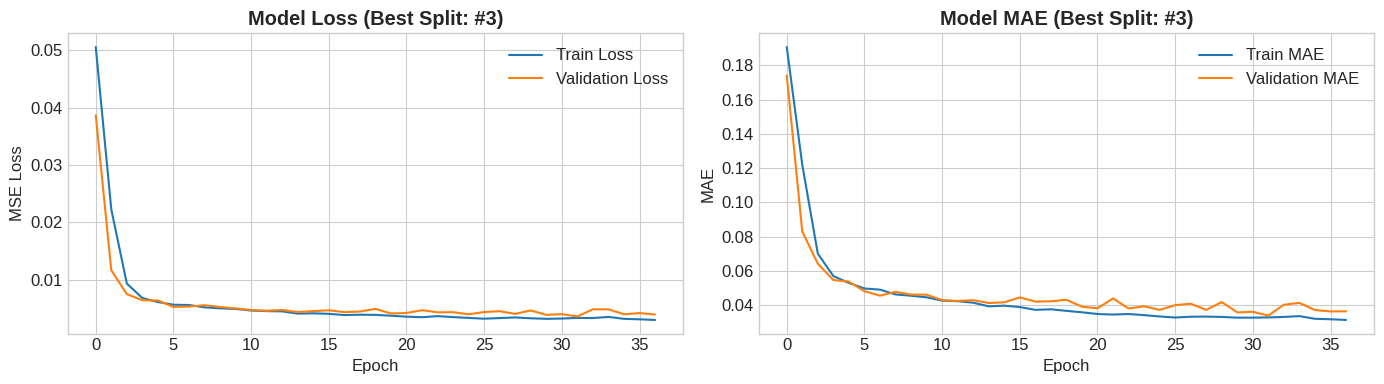

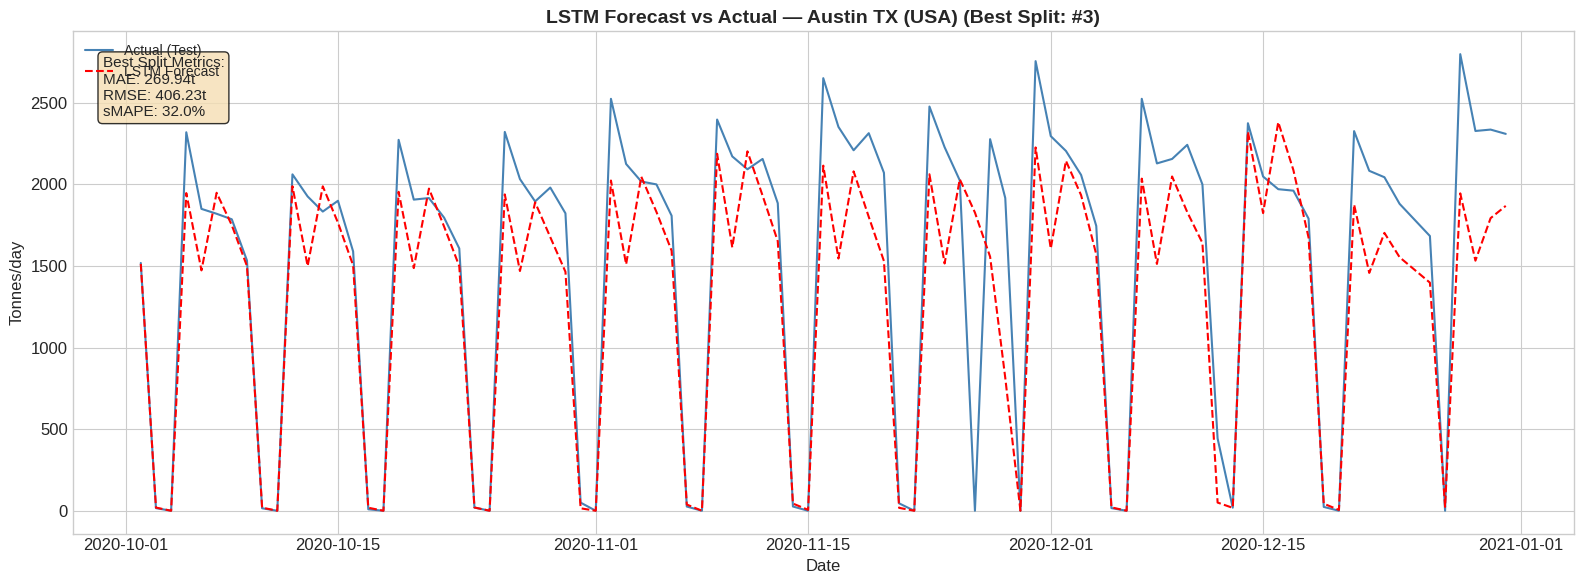

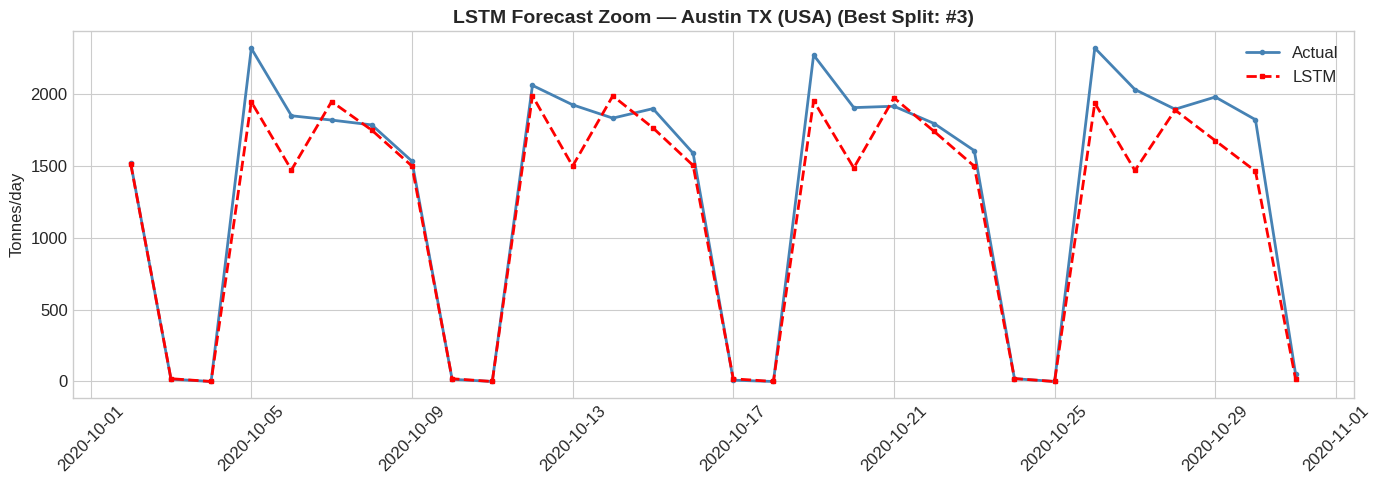


LSTM PREDICTION — Ballarat (Australia)
Total rows: 4717, Valid (non-NaN in target & features): 4703

Rolling-origin validation: 3 splits of 90 days each (lookback=30)

--- Split 1/3 ---
Train: 4433 days (2001-02-01 → 2013-04-03)
Test:  90 days (2013-04-04 → 2013-07-02)
Training finished at epoch 23
MAE: 8.54t | RMSE: 11.41t | sMAPE: 67.86%

--- Split 2/3 ---
Train: 4523 days (2001-02-01 → 2013-07-02)
Test:  90 days (2013-07-03 → 2013-10-01)
Training finished at epoch 19
MAE: 11.49t | RMSE: 17.70t | sMAPE: 53.44%

--- Split 3/3 ---
Train: 4613 days (2001-02-01 → 2013-10-01)
Test:  90 days (2013-10-02 → 2013-12-31)
Training finished at epoch 20
MAE: 10.57t | RMSE: 14.83t | sMAPE: 31.25%

--- AVERAGE ACROSS 3 SPLITS ---
MAE:   10.20 tonnes
RMSE:  14.65 tonnes
sMAPE: 50.85%
Best split was Split 3 (sMAPE: 31.25%)


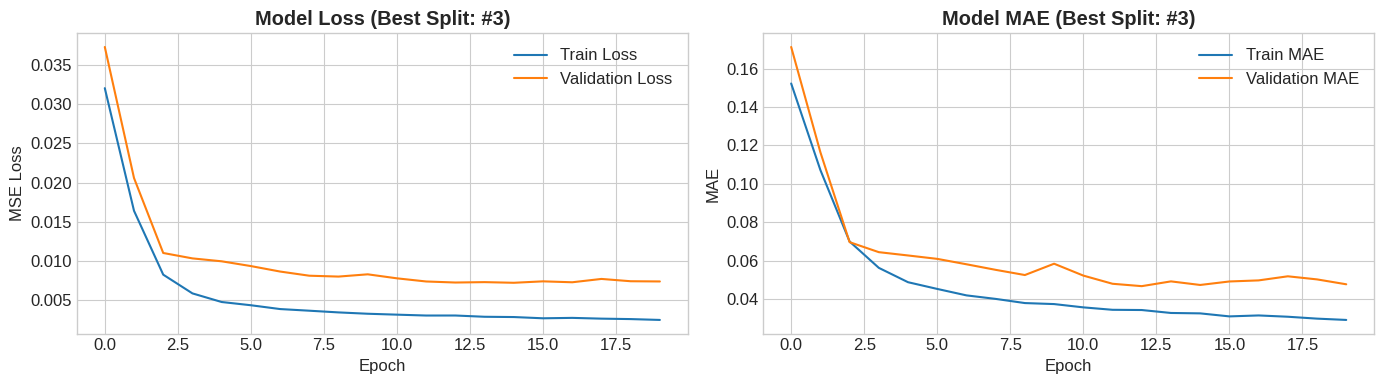

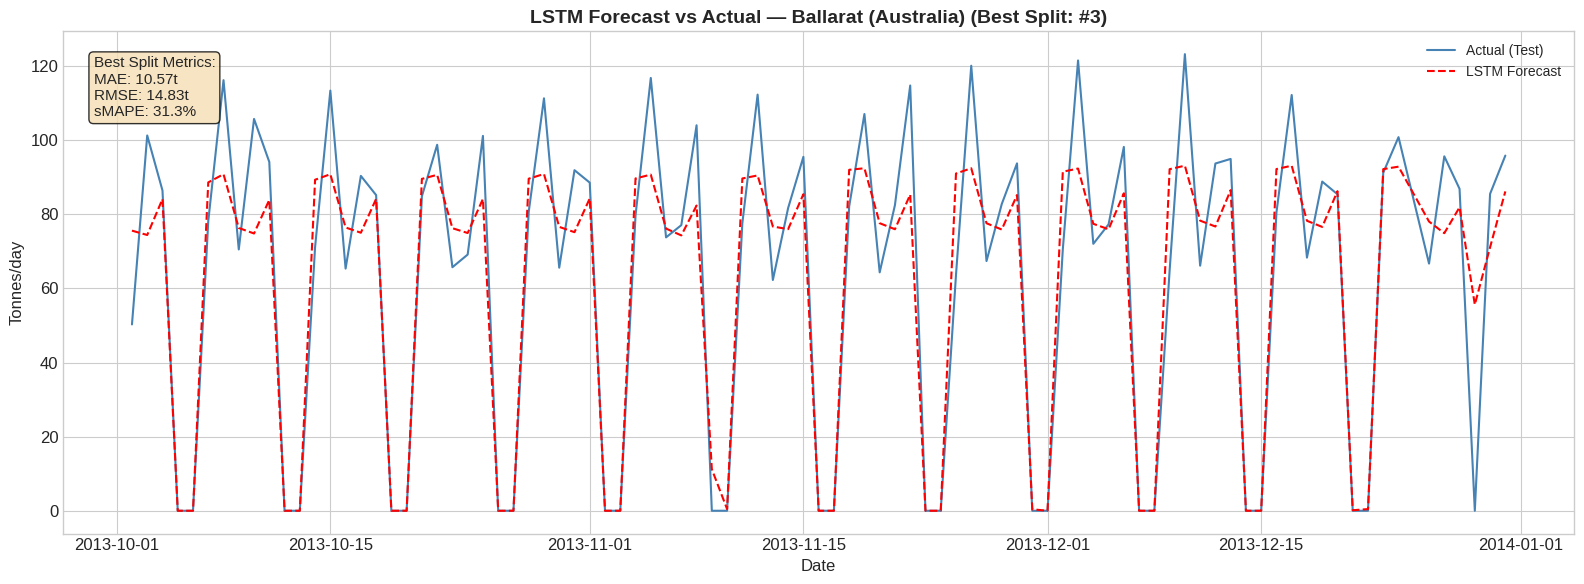

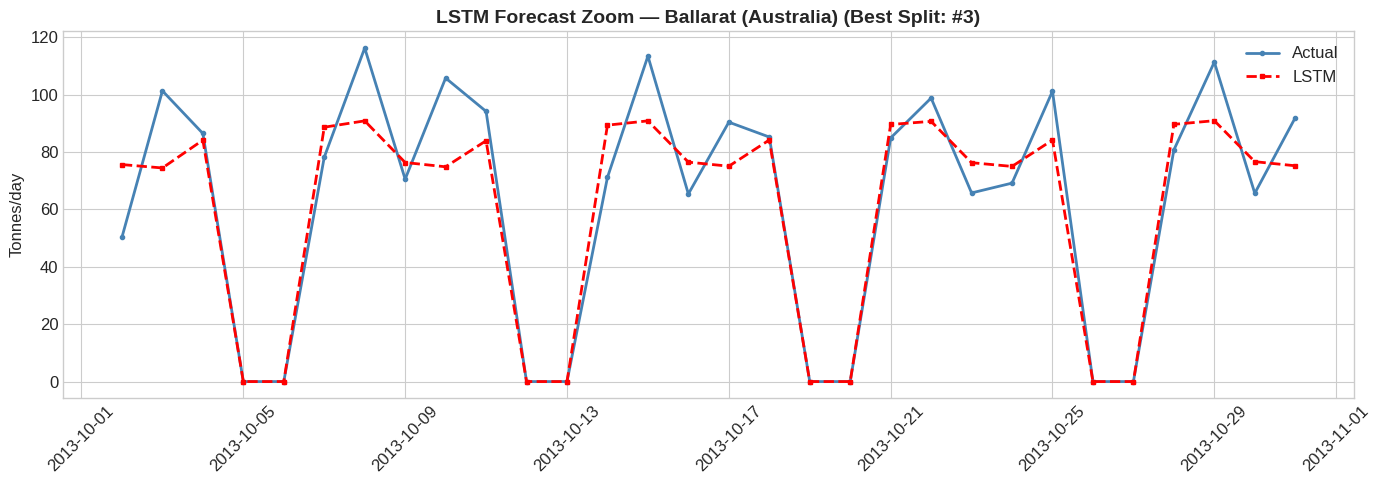

In [13]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_lstm_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            features = FEATURES,
            split_days = 90,
            n_splits = 3,
            lookback = 30,
            epochs = 50,
            batch_size = 32,
            TARGET = TARGET,
            VIS_DIR = VIS_DIR
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [14]:
print("\n" + "=" * 100)
print("LSTM RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\nValidation: Rolling-origin with {all_results[0]['n_splits']} splits of {all_results[0]['split_days']} days")
print(f"Metrics are AVERAGED across splits.")
print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'sMAPE (%)':>9s} | {'Avg Epochs':>10s}")
print("-" * 78)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['smape']:>8.2f}% | {row['epochs_trained']:>10d}")

# Average
print("-" * 78)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['smape'].mean():>8.2f}% |")

# Per-split detail
print(f"\n--- Per-split details ---")
for _, row in results_df.iterrows():
    print(f"\n{row['dataset']}:")
    for j, s in enumerate(row['split_details']):
        print(f"  Split {j+1}: MAE={s['mae']:.2f}t, RMSE={s['rmse']:.2f}t, sMAPE={s['smape']:.2f}%, Epochs={s['epochs_trained']}")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'lstm_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/lstm_results.csv")


LSTM RESULTS SUMMARY — ALL DATASETS

Validation: Rolling-origin with 3 splits of 90 days
Metrics are AVERAGED across splits.

Dataset                        |  MAE (t) |  RMSE (t) | sMAPE (%) | Avg Epochs
------------------------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     7.21 |      9.27 |    28.32% |          7
Dehiwala MC (Sri Lanka)        |    36.29 |     45.92 |    27.85% |          6
Homagama PS (Sri Lanka)        |    11.02 |     14.43 |    32.83% |         10
Moratuwa MC (Sri Lanka)        |    16.71 |     22.23 |    24.71% |         16
Austin TX (USA)                |   176.87 |    255.80 |    42.48% |         33
Ballarat (Australia)           |    10.20 |     14.65 |    50.85% |         20
------------------------------------------------------------------------------
AVERAGE                        |    43.05 |     60.38 |    34.51% |

--- Per-split details ---

Boralesgamuwa UC (Sri Lanka):
  Split 1: MAE=8.50t, RMSE=10.39t, s

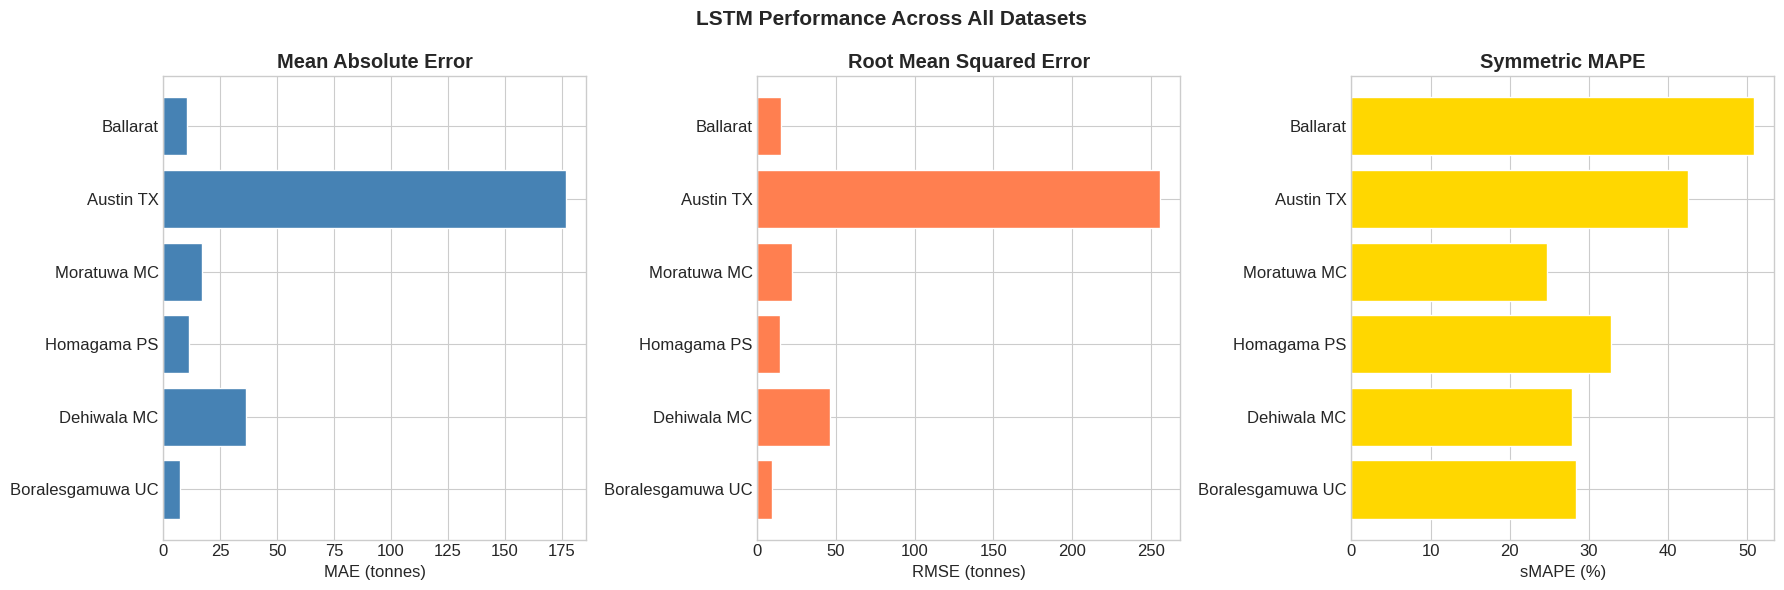

In [15]:
# --- Plot 301: LSTM Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# sMAPE
axes[2].barh(short_names, results_df['smape'], color='gold', edgecolor='white')
axes[2].set_xlabel('sMAPE (%)')
axes[2].set_title('Symmetric MAPE', fontweight='bold')

plt.suptitle('LSTM Performance Across All Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '301_lstm_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()